In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import uproot
from xgboost import XGBRegressor
# 阈值变量
r_cut_low, r_cut_high = 300, 450
theta_cut_low, theta_cut_high = np.deg2rad([0, 35])
log10TeV_low=1.8; log10TeV_high=2.3

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")
import json
        
# 加载线性参数
with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
    lp = json.load(f)
intercept  = lp["intercept"]
coef_NuW3  = lp["coef"][0]
coef_theta = lp["coef"][1]

def energy_rec(df):
    df['NuW3'] = pd.to_numeric(df['NuW3'], errors='coerce')
    df['NuW3'] = np.log10(df['NuW3'])
    # 4. XGBoost 能量修正
    features = df[["NuW3", "rec_theta"]].values
    df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
    return df



npz_file="/data/home/zzh/data/Dataset_Filted/Experiment/1e10_V04/1e10_V04_2023_ALL_MERGED.npz"
data = np.load(npz_file, allow_pickle=True); df = pd.DataFrame(data['params'], columns=data['param_names']); del data
# df = pd.read_csv("/data/home/zzh/data/Dataset_Filted/Experiment/Rue1less_minus2/2024_Rue_minus1.9_noAge_cut_1e10_V04_dataset_fastcode.csv"); print(f'Loaded {len(df)}')
df['rec_x'] = pd.to_numeric(df['rec_x'], errors='coerce'); df['rec_y'] = pd.to_numeric(df['rec_y'], errors='coerce'); df['rec_r']=np.sqrt(df['rec_x']**2 + df['rec_y']**2)
df = energy_rec(df)
exp_Rue_df = df[(df['rec_r']>r_cut_low) & (df['rec_r']<r_cut_high) & (df['rec_theta'] > theta_cut_low) & (df['rec_theta'] < theta_cut_high)]
print(f"\n Exp data: {len(exp_Rue_df)} events")

# R_ue control region df
# one_day_data=pd.read_csv("/data/home/zzh/data/Dataset_Filted/Experiment/exp_muons/2023_0101_1e10_V04_dataset_muon.csv"); print(f'Loaded {len(one_day_data)}')
one_day_file="/data/home/zzh/data/Dataset_Filted/Simulation/1e10_V04/exp_1e10_V04_20230101_226files_dataset_fastcode.npz"
one_day= np.load(one_day_file, allow_pickle=True)
one_day_data = pd.DataFrame(one_day['params'], columns=one_day['param_names']); del one_day
one_day_data = energy_rec(one_day_data)
one_day_data['rec_x']= pd.to_numeric(one_day_data['rec_x'], errors='coerce'); one_day_data['rec_y'] = pd.to_numeric(one_day_data['rec_y'], errors='coerce'); one_day_data['rec_r']=np.sqrt(one_day_data['rec_x']**2 + one_day_data['rec_y']**2)
one_day_df = one_day_data[(one_day_data['rec_r']>r_cut_low) & (one_day_data['rec_r']<r_cut_high) & (one_day_data['rec_theta'] > theta_cut_low) & (one_day_data['rec_theta'] < theta_cut_high)]
print(f"One day data: {len(one_day_df)} events")


 Exp data: 28820 events
One day data: 70665 events


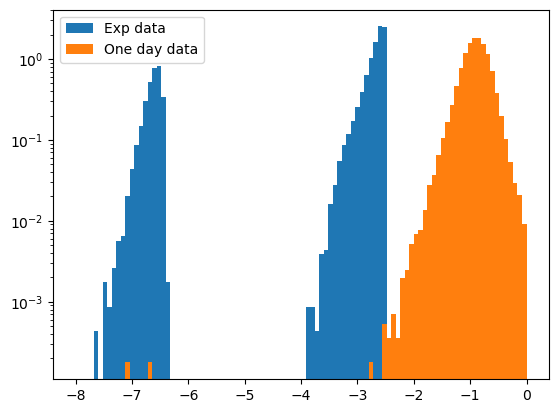

In [5]:
plt.hist(exp_Rue_df['R_ue'], bins=100, range=(-8, 0), density=True, label='Exp data')
plt.hist(one_day_df['R_ue'], bins=100, range=(-8, 0), density=True, label='One day data')
plt.legend()
plt.yscale('log')
plt.show()
